# Figure Factory

In [2]:
# set up paths to local module
import os
import sys 
from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))
from decanopy.models.RSC import heat_mapping_helper as hm

import pickle
import numpy as np 

# plotting import and settings
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Garamond', 'EB Garamond'] + plt.rcParams['font.serif']

## Data

In [3]:
# INPUT: skytype and list of runs to load
skytype = "real_sky"
runlist = ["np_az_alt", "heatmap"]

# NOTE: right now the code is set up to load different runs for the same sky type. We can relax this assumption later. 

In [4]:
# read all the dictionaries from the list above
# data will be stored in data_dicts with the run name as the key

readpath = PROJECT_ROOT / "data" / "output"  / "RSC" / skytype
data_dicts = {}
data_paths = {}

for name in runlist:
    dictname = name + "_dict"
    dictpath = readpath / name / dictname
    with open(dictpath, "rb") as f:
        data_dicts[name] = pickle.load(f)    
        data_paths[name] = readpath / name
        #data = pickle.load(f)
        #globals()[name] = data
        #globals()[name] = pickle.load(f)
        #dictlist.append(dictname)

print("Dictionaries loaded: ", list(data_dicts.keys()))

Dictionaries loaded:  ['np_az_alt', 'heatmap']


In [5]:
# define N&P data 
# calculated from NP sheet in NP_data.xlsx

uscNP = 48 # 47+1 because of the "?"", maybe?
histNP = {-3: 14, -2: 15, -1: 49, 0: 138, 1: 45, 2: 25, 3: 26} # total of 312 stars
R0NP, R1NP, RsNP = hm.compute_ratios(histNP)

## Figures

In [6]:
# INPUT: select the dictionary to use for plotting

key = "np_az_alt"
source_dict = data_dicts[key]
savepath = data_paths[key] / "Figures" 

# Figures will be saved in the "Figures" folder of the selected run

### Individual heatmaps

In [8]:
# helper dictonaries and function for plotting

title_dict = {
    "unicount": "Unique star counts for", 
    "R0": "$R_0$ for ",
    "R1": "$R_1$ for ",
    "S": "$R_s$ for "
    }

clabel_dict = {
    "unicount": "unique star count minus N&P value", 
    "R0": "$R_0 - R_0^{N&P}$",
    "R1": "$R_1 - R_1^{N&P}$",
    "S": "$R_s - R_s^{N&P}$"
    }

ref_vals_dict = {
    "unicount": uscNP, 
    "R0": R0NP,
    "R1": R1NP,
    "S": RsNP
}

clims_dict = {
    "unicount": (-20, 0, 20), 
    "R0": (-R0NP, R0NP),
    "R1": (-R1NP, R1NP),
    "S":  (-RsNP, RsNP)
}

def save_plots(sky_dict, name, metric, savepath):
    # metric-specific things
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    title = title_dict[metric] + name + " Select"
    clabel = clabel_dict[metric]
    savepath = savepath / metric 

    if not os.path.exists(savepath):
        os.makedirs(savepath)
    
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(sky_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value

    # dark figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "twilight", clims = clims, clabel = clabel)
    figname = metric + "_" + name + "_dark.png"
    fig.savefig(savepath / figname)
    plt.close(fig)

    # light figure
    fig, ax  = hm.plot_heatmap(grid, title, cmap = "BrBG", clims = clims, clabel = clabel)
    figname = metric + "_" + name + "light.png"
    fig.savefig(savepath / figname)
    plt.close(fig) 


In [9]:
# iterate through selectiomn algorithms and metric choices
select_algs = ['Mag', 'Name', 'DBC', 'CBin', 'Full']
metric_keys = ['unicount', 'R0', 'R1', 'S']

# save all algo and metric figures
for name in select_algs: 
    for metric in metric_keys:
        save_plots(source_dict, name, metric, savepath)

### 3x1 grids of heatmaps

In [10]:
# savepath for grids

gridpaths = savepath / "3x1grids"
if not os.path.exists(gridpaths):
        os.makedirs(gridpaths)

Below I iterate through each metric I want and save the 3x1 grid for three select algorithms. If in the future we want all of these for a bunch of runs, we can wrap it in a function. :)

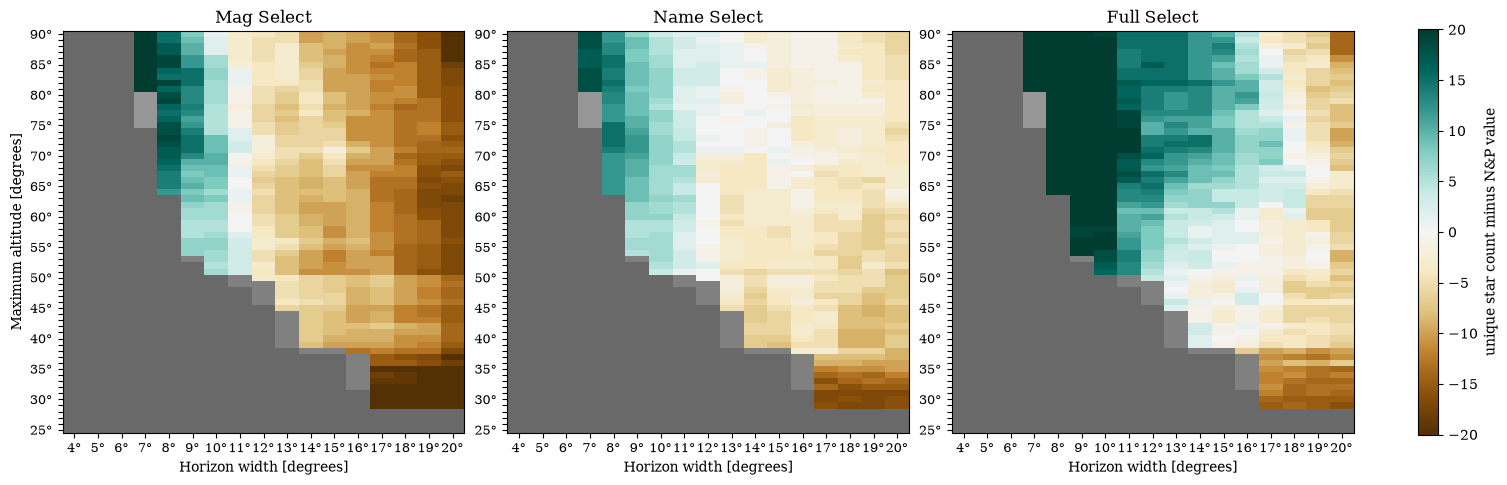

In [11]:
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'unicount'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(source_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)


fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

# select name and save figure 
figname = metric + "_3x1grid.png"
fig.savefig(gridpaths / figname)

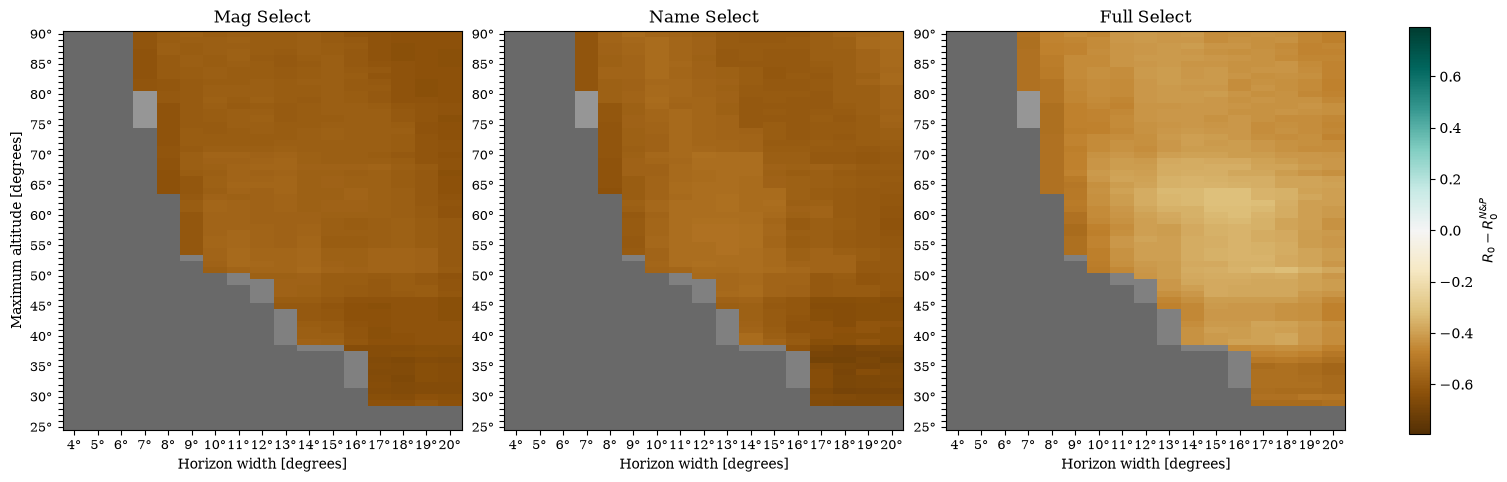

In [12]:
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'R0'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(source_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)


fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

# select name and save figure 
figname = metric + "_3x1grid.png"
fig.savefig(gridpaths / figname)

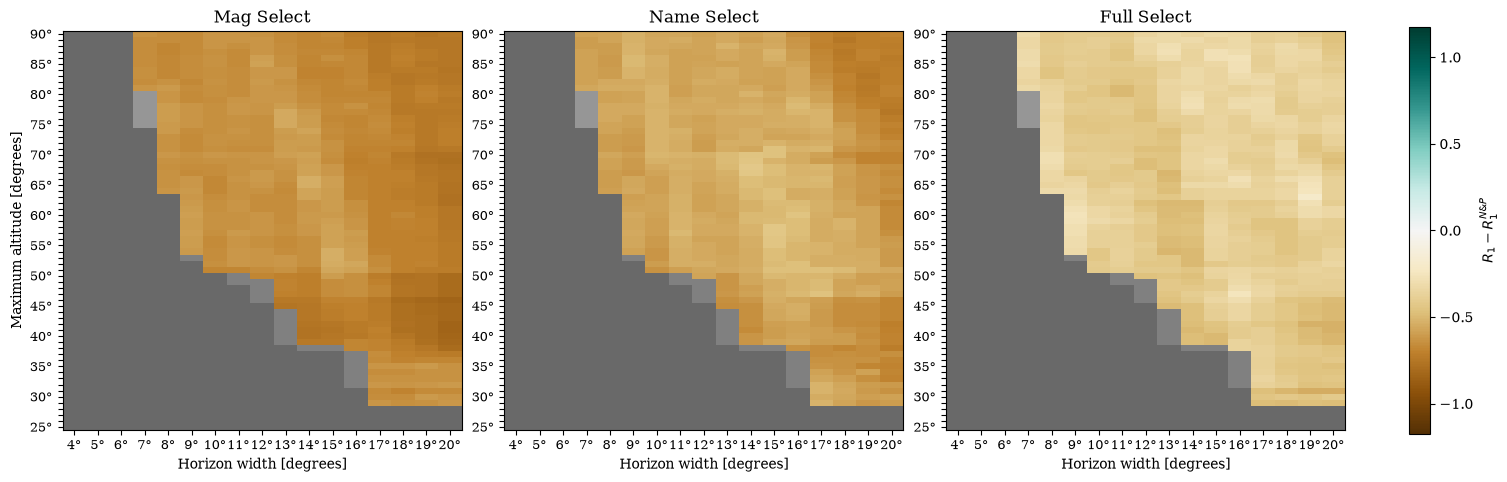

In [13]:
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'R1'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(source_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)


fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

# select name and save figure 
figname = metric + "_3x1grid.png"
fig.savefig(gridpaths / figname)

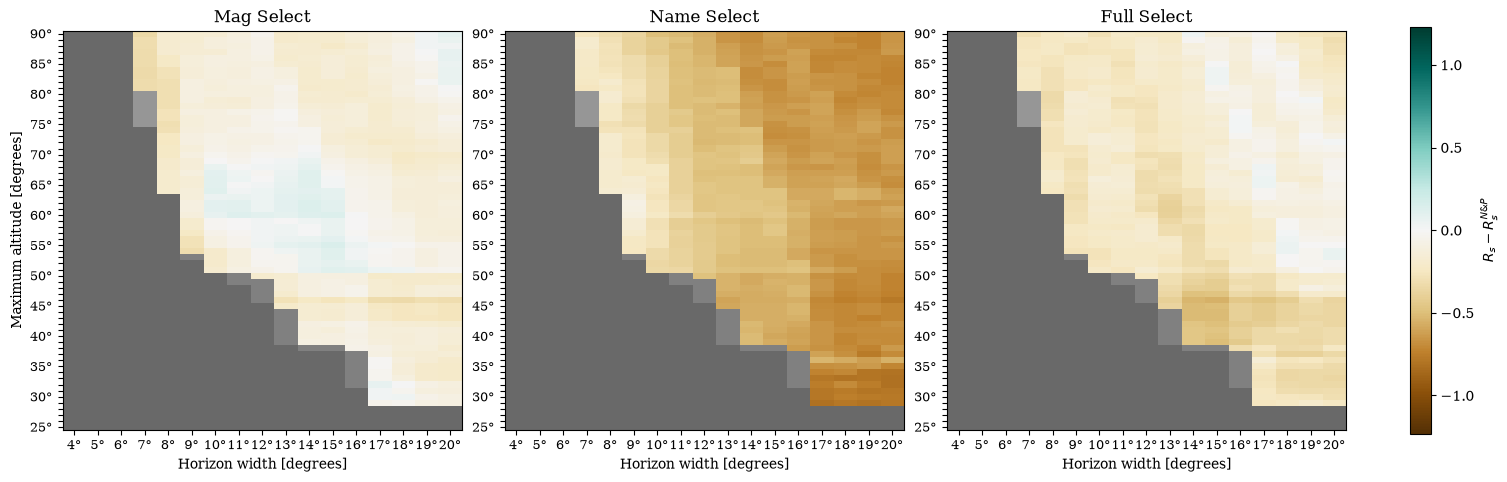

In [14]:
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'S'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(source_dict[name], metric=metric)
    grid[grid >= 0] -= ref_val # subtract reference value
    gridlist.append(grid)


fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

# select name and save figure 
figname = metric + "_3x1grid.png"
fig.savefig(gridpaths / figname)

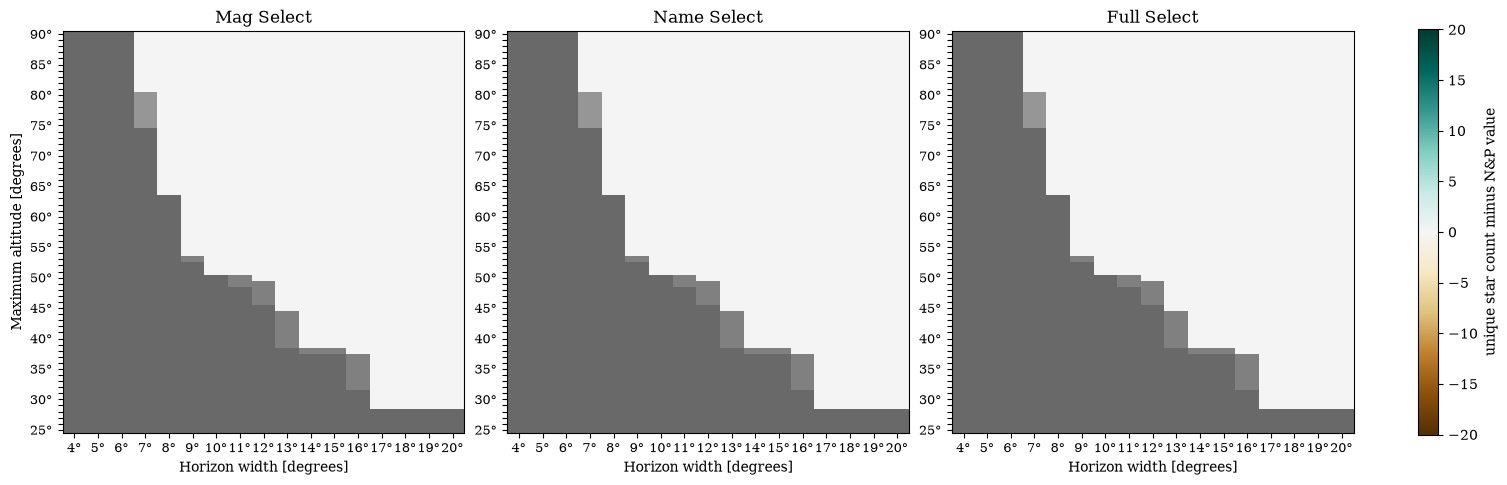

In [15]:
select_algs = ['Mag', 'Name', 'Full']


# iterate through selectiomn algorithms
metric = 'unicount'
gridlist = []
titles = []

for name in select_algs:
    # plotting niceties
    titles.append(name + " Select")
    clabel = clabel_dict[metric]
    ref_val = ref_vals_dict[metric]
    clims = clims_dict[metric]
    #calculate & normalize grid
    grid = hm.make_heatmap_grid(source_dict[name], metric=metric)
    grid[grid >= 0] = 0 # testing
    gridlist.append(grid)


fig, axs  = hm.plot_heatmap_grid(gridlist, titles, 
                                 cmap = "BrBG", clims = clims, clabel = clabel, figsize = (15, 5))

# select name and save figure 
figname = "fails" + "_3x1grid.png"
fig.savefig(gridpaths / figname)

### Histograms

In [16]:
# savepath for histograms

histpaths = savepath / "histograms"
if not os.path.exists(histpaths):
        os.makedirs(histpaths)

In [17]:
# prep data for plotting histograms

# N&P
keys = [-3, -2, -1, 0, 1, 2, 3]
name = 'N&P data'
valsNP = [histNP[k] for k in keys]

# Name algorithm
name = 'Name'
hist = hm.make_heatmap_grid(source_dict[name], metric='hist')
valsName = [hist[20][65][k] for k in keys]

# Full algorithm
name = 'Full'
hist = hm.make_heatmap_grid(source_dict[name], metric='hist')
valsFull = [hist[20][65][k] for k in keys]

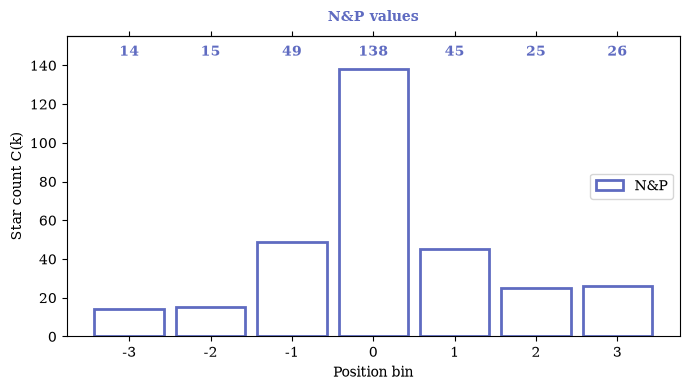

In [54]:
# N&P data
# - - - - - - - - - - - 

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)

# bottom axis
ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels

# top axis for N&P numbers
secax = ax.secondary_xaxis('top')
secax.set_xticklabels([])  # Clears existing labels
secax.set_xlabel("N&P values", color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels([0]+valsNP, color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels(valsNP)  # Clears existing labels


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 155)
#ax.set_title("Histogram of Star Positions")
ax.legend(loc = 'center right')

fig.tight_layout()

# select name and save figure 
figname = "np_histogram.png"
fig.savefig(histpaths / figname)

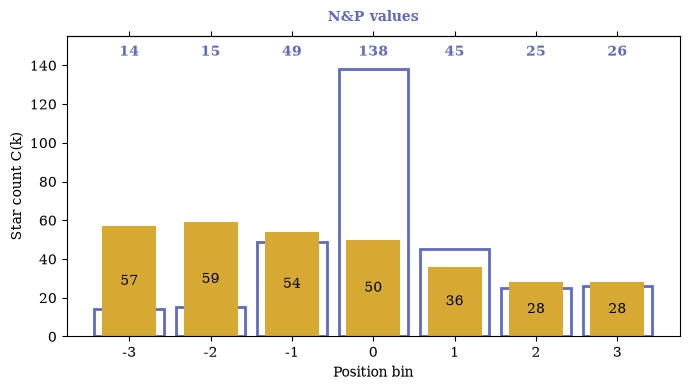

In [18]:
# Name data
# - - - - - - - - - - - 

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
#ax.bar_label(bar1, padding=10, color = "#5F6BC1", weight = 'bold')
bar2 = ax.bar(x, valsName, 1.75* width, label='Name', color="#D5A932")
ax.bar_label(bar2, padding=0, label_type='center')

# bottom axis
ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels

# top axis for N&P numbers
secax = ax.secondary_xaxis('top')
secax.set_xticklabels([])  # Clears existing labels
secax.set_xlabel("N&P values", color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels([0]+valsNP, color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels(valsNP)  # Clears existing labels


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 155)
#ax.set_title("Histogram of Star Positions")
#ax.legend(loc = 'center right')

fig.tight_layout()

# select name and save figure 
figname = "np+name_histogram.png"
fig.savefig(histpaths / figname)

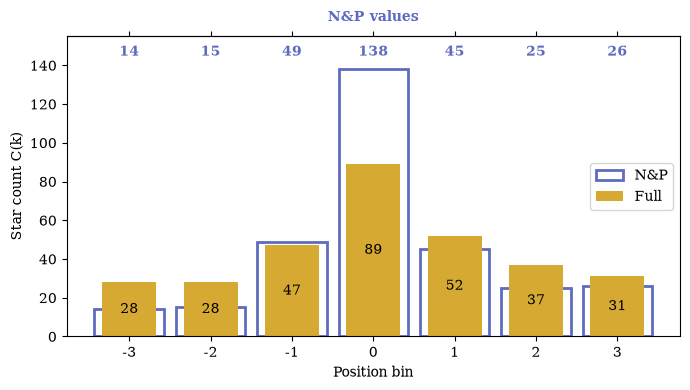

In [19]:
# Full data
# - - - - - - - - - - - 

x = np.arange(len(keys))   # numerical positions for grouping
width = 0.38               # width of each individual bar

fig, ax = plt.subplots(figsize=(7, 4))
bar1 = ax.bar(x, valsNP, 2.25*width, label='N&P', fill=False, edgecolor="#5F6BC1", linewidth=2)
#ax.bar_label(bar1, padding=10, color = "#5F6BC1", weight = 'bold')
bar2 = ax.bar(x, valsFull, 1.75* width, label='Full', color="#D5A932")
ax.bar_label(bar2, padding=0, label_type='center')

# bottom axis
ax.set_xticks(x)
ax.set_xticklabels(keys)    # keep the original -3 … 3 labels

# top axis for N&P numbers
secax = ax.secondary_xaxis('top')
secax.set_xticklabels([])  # Clears existing labels
secax.set_xlabel("N&P values", color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels([0]+valsNP, color = "#5F6BC1", weight = 'bold')  # Clears existing labels
#secax.set_xticklabels(valsNP)  # Clears existing labels


for i in range(0, len(x)): 
    ax.text(x[i], 145, str(valsNP[i]), ha='center', color = "#5F6BC1", weight = 'bold')

ax.set_xlabel("Position bin")
ax.set_ylabel("Star count C(k)")
ax.set_ylim(0, 155)
#ax.set_title("Histogram of Star Positions")
ax.legend(loc = 'center right')

fig.tight_layout()

# select name and save figure 
figname = "np+full_histogram.png"
fig.savefig(histpaths / figname)